# LAB 2

Den første delen av LABEN er å opprette et **11 kV distribusjonsnett** basert på de oppgitte nettdataene. Den andre delen er å utføre ulike beregninger og analyser av nettet. 

Du skal levere inn to dokumenter i Canvas:

1. En **.pfd-fil** av kraftsystemmodellen din (*.pfd er filformatet som benyttes av PowerFactory, og er IKKE det samme som PDF-formatet*).
2. Et dokument som presenterer simuleringsresultatene for de ulike oppgavene.

# 3 OPPGAVE 1: NETTKONFIGURASJON

## NETTTOPOLOGI OG NAVNGIVING

Figur 1 viser topologien til nettet. Nettverket består av én krafttransformator **132/11 kV (T1)** og tre distribusjonstransformatorer **11/0,230 kV** som forsyner boliger med elektrisk energi.

Vennligst bruk den samme navnekonvensjonen som vist i figuren.

In [1]:
# TEST CELL
from IPython.display import IFrame

IFrame("../images/LAB2grid.svg", width=1000, height=600)

## TRANSFORMATORDATA

Tabell 1 viser verdiene som skal legges inn for transformatorene under **Type → Base Data**. Alle andre data skal forbli uendret.

### Tabell 1. Transformatordata

| Navn | Fra samleskinne | Til samleskinne | V_HV kV | V_LV kV | Merkeytelse | Kortslutningsspenning $u_k$ |
|------|----------------|----------------|----------------|----------------|-------------|------------------------------|
| T1 | HV Bus | LV Bus | 132 | 11 | 40 MVA | 3 % |
| T2 | Area 1 HV | Area 1 LV | 11 | 0,23 | 400 kVA | 6 % |
| T3 | Area 2 HV | Area 2 LV | 11 | 0,23 | 700 kVA | 6 % |
| T4 | Area 3 HV | Area 3 LV | 11 | 0,23 | 2,0 MVA | 6 % |

### EKSTERNT NETT (EXTERNAL GRID)

I komponenten **External Grid**, gå til fanen **«Short-Circuit Complete»**, slik vist i figur 2.

Endre følgende parametere:

- Maksimalt kortslutningsnivå $S''_{k,\text{max}}$ til **100 MVA**
- Minimalt kortslutningsnivå $S''_{k,\text{min}}$ til **60 MVA**

Disse verdiene angir henholdsvis den høyeste og laveste tilgjengelige kortslutningsytelsen fra det overliggende nettet og benyttes ved kortslutningsberegninger i kraftsystemmodellen.

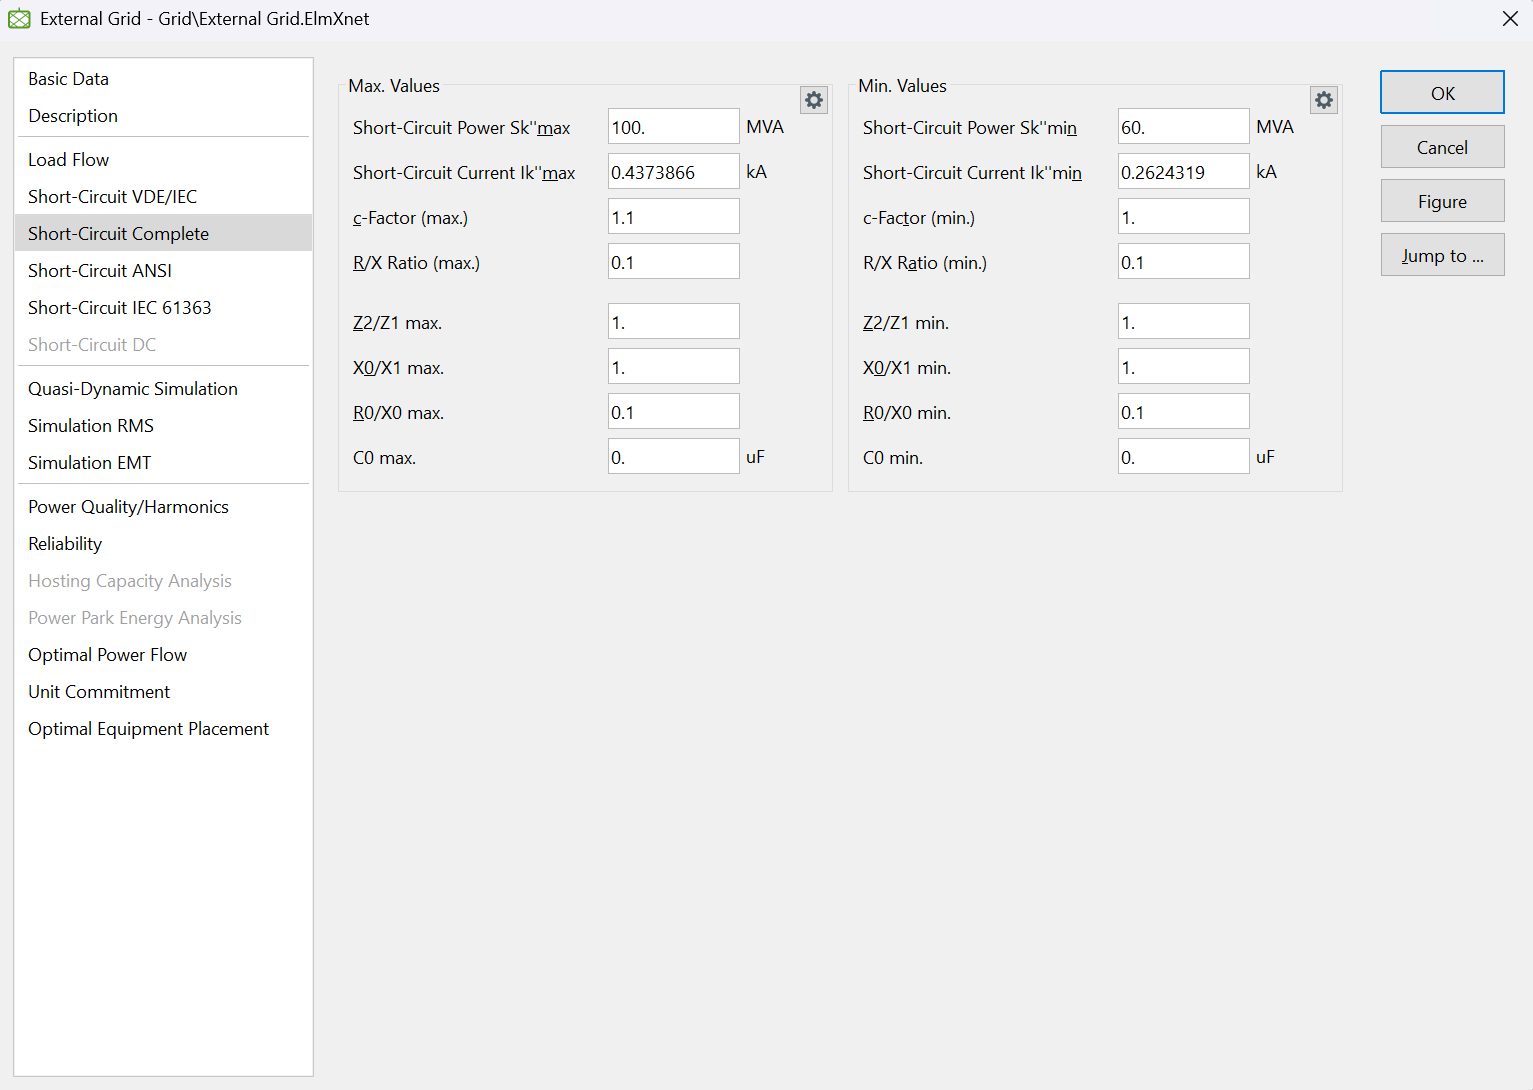

In [2]:
# TEST CELL
from IPython.display import Image

Image("../images/LAB2extgrid.png", width=1000, height=800)

## LASTDATA

Fyll inn aktiv effekt og effektfaktor for de ulike lastene i systemet. Dataene for lastene er gitt i tabell 2 nedenfor.

### Tabell 2: Lastdata for de tre forsyningsområdene

| Last | Aktiv effekt [kW] | Effektfaktor |
|--------|--------:|--------:|
| Lastområde 1 | 150 | 0,96 (induktiv) |
| Lastområde 2 | 400 | 0,96 (induktiv) |
| Lastområde 3 | 1500 | 0,96 (induktiv) |

---

## KABLER

Legg inn kabellengde, resistans, reaktans og kapasitans i PowerFactory-modellen i henhold til dataene i tabell 3.

Se **Vedlegg 1** for tekniske data for **Draka-kabelen**. Ved oppslag av kabeldata skal **flat kabelkonfigurasjon (flat cable configuration)** benyttes.

### Merk

For å legge inn kabelens kapasitansverdi:

1. Åpne kabeltypen i PowerFactory.
2. Gå til fanen **«Load Flow»**.
3. Klikk på **tannhjulsikonet (Gear Symbol)**.
4. Endre inndatatypen fra **Susceptance B′** til **Capacitance C′**, slik vist i figur 2.
5. Legg deretter inn kapasitansverdien fra kabeldataene.

Dette sikrer at kabelkapasitansen registreres direkte som kapasitans per lengdeenhet i modellen.

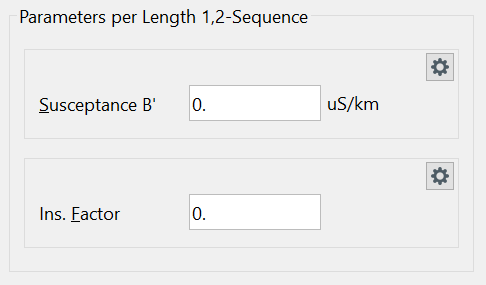

In [4]:
# TEST CELL
from IPython.display import Image

Image("../images/LAB2cable.png", width=500, height=400)

### Tabell 3: Kabeldata

| Kabel | Mellom samleskinner | Kabelmerke/-type | Kabelegenskaper per km | Lengde |
|---------|-------------------|------------------|-------------------------|---------|
| Kabel 1 | LV Bus og Area 1 HV | TSLI 12/20 (24) kV Cu 3x1x150 | Se Vedlegg 1 | 200 m |
| Kabel 2 | Area 1 HV og Area 2 HV | TSLI 12/20 (24) kV Cu 3x1x150 | Se Vedlegg 1 | 2000 m |
| Kabel 3 | Area 2 HV og Area 3 HV | TSLI 12/20 (24) kV Cu 3x1x150 | Se Vedlegg 1 | 1000 m |

Kabelegenskapene som skal legges inn for hver kabel er:

- Resistans \(R\) [Ω/km]
- Reaktans \(X\) [Ω/km]
- Kapasitans \(C\) [μF/km]

Verdiene hentes fra **Vedlegg 1** for kabeltypen **TSLI 12/20 (24) kV Cu 3x1x150**.

---

# EKSPORTER MODELLEN DIN

Når alle nettkomponenter og tilhørende data er lagt inn, skal modellen eksporteres fra PowerFactory til en **.pfd-fil (PowerFactory Data File)**.

Fremgangsmåte:

1. Velg **File → Export → Data (*.pfd; *.dz)**.
2. Velg modellen du nettopp har opprettet.
3. Klikk **OK**.
4. PowerFactory vil spørre om prosjektet skal deaktiveres.
5. Klikk **Yes**.

Den eksporterte **.pfd-filen** skal leveres sammen med besvarelsen i Canvas.

---

# OPPGAVE 2 – LASTFLYTANALYSE 

I denne oppgaven skal du utføre lastflytberegninger (Load Flow / Power Flow) for å bestemme:

- Spenninger i nettet
- Effekttap i nettet
- Belastningsgrad for transformatoren

## a)

Utfør en lastflytanalyse i PowerFactory.

Besvar oppgaven med et bilde av nettet der beregningsresultatene vises.

---

## b)

Anta at du skal legge til en ekstra last på **200 kW** i systemet.

Denne lasten kan kobles til enten:

- Area 1 (LV-siden)
- Area 2 (LV-siden)
- Area 3 (LV-siden)

Hvor ville du plassert denne lasten?

Begrunn svaret ditt.

**Merk:** Fjern den ekstra lasten etter at denne deloppgaven er gjennomført.

---

## c)

Endre lengden på **Kabel 1** til **16 000 m**.

Denne kabelverdien skal benyttes inntil annet blir oppgitt.

Utfør deretter en ny lastflytanalyse og presenter resultatene på samme måte som i oppgave a).

Vurder om kraftsystemet fortsatt har tilfredsstillende nettdrift.

Begrunn svaret med utgangspunkt i spenningsnivåene på samleskinnene (busbarene).

---

## d)

Hvor store aktive effekttap oppstår i nettet under simuleringen i oppgave 2 c)?

Oppgi svaret i passende enhet (kW eller MW) og kommenter resultatet.

---

# OPPGAVE 3 – KORTSLUTNINGSANALYSE 

Ved utførelse av kortslutningsberegninger skal beregningsmetoden **«Complete»** benyttes.

Denne beregningsmetoden velges før kortslutningsanalysen kjøres, slik vist i figuren under.

Kortslutningsanalysen skal brukes til å bestemme strømmer og nettforhold ved feiltilstander, og resultatene skal analyseres i de påfølgende deloppgavene.

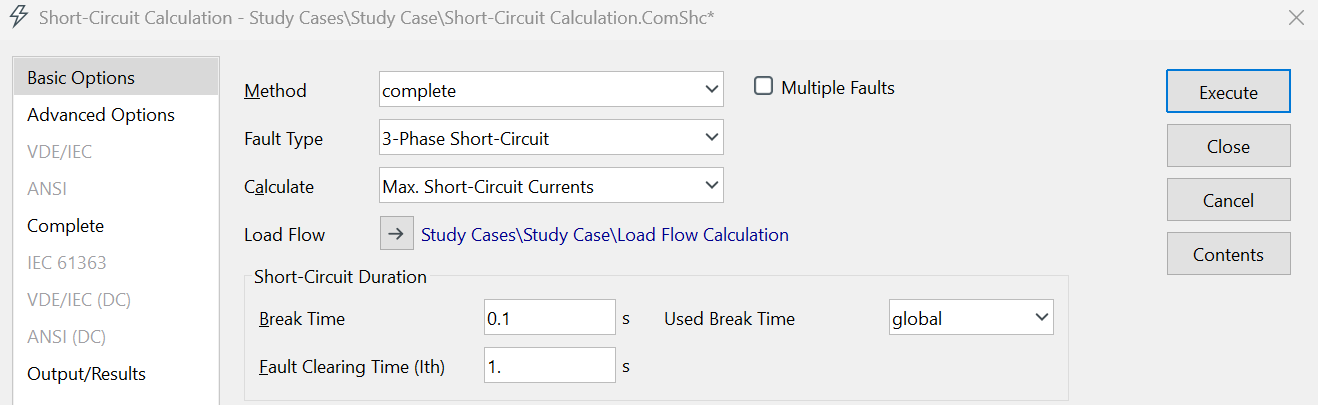

In [6]:
# TEST CELL
from IPython.display import Image

Image("../images/LAB2short_circuit.png", width=1000, height=800)

Før kortslutningsanalysene utføres, skal lengden på **Kabel 1** endres tilbake til **200 m**.

---

## a)

Beregn følgende for hver samleskinne (busbar) i nettet:

- Maksimal trefase kortslutningsstrøm
- Minimal trefase kortslutningsstrøm

Bruk PowerFactory til å utføre beregningene.

Besvar oppgaven med et skjermbilde som viser resultatene for alle samleskinnene.

---

## b)

Forklar kort hvorfor kortslutningsverdiene er forskjellige mellom de ulike samleskinnene i nettet.

Hint: Vurder avstanden til spenningskilden og den totale impedansen mellom feilstedet og nettet.

---

## c)

Beregn kortslutningsytelsene i nettet manuelt ved hjelp av impedansmetoden.

Resultatene skal presenteres i en tabell.

Rapporten skal inneholde:

- Fremgangsmåte
- Nødvendige formler
- Mellomregninger
- Endelige resultater

Sammenlign gjerne de manuelle beregningene med resultatene fra PowerFactory.

---

## Endring av nettdata

Endre kortslutningsytelsen i det eksterne nettet til:

- Maksimal kortslutningsytelse $S''_{k,\text{max}}$ = **1000 MVA**
- Minimal kortslutningsytelse $S''_{k,\text{min}}$ = **600 MVA**

Disse verdiene skal benyttes i resten av oppgaven.

---

## d)

Utfør nye kortslutningsberegninger i PowerFactory.

Bestem kortslutningsverdiene ved distribusjonstransformatorene med de oppdaterte verdiene for det eksterne nettet.

Denne deloppgaven skal løses ved hjelp av datasimulering.

---

## e)

Sammenlign resultatene fra oppgave a) og oppgave d).

Forklar kort hvorfor resultatene er forskjellige.

Fokuser spesielt på hvordan endringen i tilgjengelig kortslutningsytelse i det eksterne nettet påvirker:

- Kortslutningsstrømmene
- Kortslutningsytelsene
- Nettets impedans sett fra feilstedet

---

## Endring av transformatorparametere

Øk den interne transformatorreaktansen (kortslutningsspenningen) $u_k$ for transformator **T1** til:

$$
u_k = 13\%
$$

---

## f)

Utfør kortslutningsberegningene på nytt etter at $u_k$ er økt til 13 %.

Presenter de nye resultatene.

---

## g)

Hvorfor er resultatene forskjellige fra resultatene i oppgave a)?

Forklar kort hvordan en økning i transformatorens kortslutningsspenning $u_k$ påvirker:

- Transformatorens impedans
- Kortslutningsstrømmen
- Kortslutningsytelsen i nettet

Begrunn svaret med relevante kraftsystemteoretiske sammenhenger.